# Law of Cosines — The Tilted Square Proof

We prove that for any triangle with sides $a$, $b$ and $c$, where $\theta$ is the angle between sides $a$ and $b$:

$$c^2 = a^2 + b^2 - 2ab\cos(\theta)$$

using a dynamic deformation of the classic **Pythagorean proof**. Instead of memorising a formula, we *watch* what happens to the four triangles inside the $(a+b)$ square when we tilt side $b$ away from 90°.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.patches import FancyArrowPatch

## Step 1 — Recall: The Pythagorean Square

Start from the proof you already know. A big square of side $(a+b)$ contains:
- **4 right triangles**, each with area $\frac{1}{2}ab$ → total area $2ab$
- **1 tilted inner square** of side $c$ → area $c^2$

The area balance gives us: $(a+b)^2 = c^2 + 2ab$, which simplifies to $a^2 + b^2 = c^2$.

**Key insight:** The $2ab$ comes entirely from the four triangles. Those four triangles have a right angle because $b$ is perpendicular to $a$.

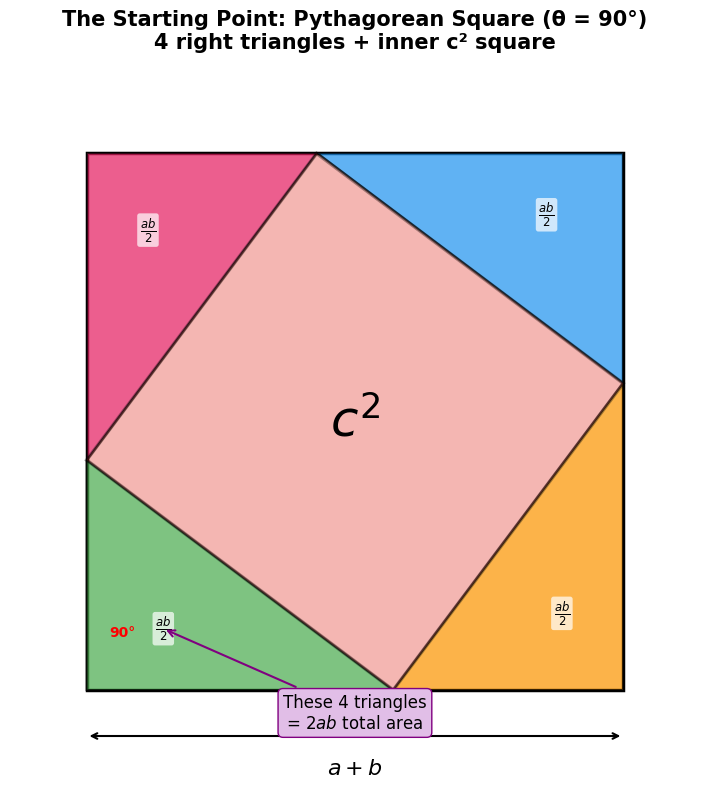

In [2]:
# === DIAGRAM 1: The classic Pythagorean square (θ = 90°) ===

a, b = 3, 4
s = a + b  # side of outer square

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xlim(-1, s + 1)
ax.set_ylim(-1, s + 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('The Starting Point: Pythagorean Square (θ = 90°)\n'
             '4 right triangles + inner c² square',
             fontsize=15, fontweight='bold', pad=20)

# Outer square
outer = patches.Rectangle((0, 0), s, s, linewidth=2.5,
                           edgecolor='black', facecolor='#f5f5f5')
ax.add_patch(outer)

# Four right triangles
tri_colors = ['#4CAF50', '#FF9800', '#2196F3', '#E91E63']
tris = [
    [(0, 0), (b, 0), (0, a)],       # bottom-left
    [(b, 0), (s, 0), (s, b)],       # bottom-right
    [(s, b), (s, s), (a, s)],       # top-right
    [(a, s), (0, s), (0, a)],       # top-left
]
for t, c in zip(tris, tri_colors):
    ax.add_patch(plt.Polygon(t, closed=True, fc=c, ec='black', lw=1.5, alpha=0.7))

# Inner c² square
inner = plt.Polygon([(0, a), (b, 0), (s, b), (a, s)], closed=True,
                     fc='#F44336', ec='black', lw=2.5, alpha=0.35)
ax.add_patch(inner)
ax.text(s/2, s/2, '$c^2$', fontsize=36, ha='center', va='center', fontweight='bold')

# Label each triangle
for (cx, cy) in [(1.0, 0.8), (s-0.8, 1.0), (s-1.0, s-0.8), (0.8, s-1.0)]:
    ax.text(cx, cy, '$\\frac{ab}{2}$', fontsize=12, ha='center', va='center',
            bbox=dict(fc='white', ec='none', alpha=0.7, boxstyle='round,pad=0.15'))

# Label sides
ax.annotate('', xy=(s, -0.6), xytext=(0, -0.6),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(s/2, -0.9, '$a + b$', fontsize=16, ha='center', va='top')

# Label the right angle in one triangle
angle_arc = patches.Arc((0, 0), 1.2, 1.2, angle=0, theta1=np.degrees(np.arctan2(a, 0)),
                         theta2=90, lw=2, color='red')
ax.add_patch(angle_arc)
ax.text(0.3, 0.7, '90°', fontsize=10, color='red', fontweight='bold')

# Arrow pointing to the 2ab
ax.annotate('These 4 triangles\n= $2ab$ total area',
            xy=(1.0, 0.8), xytext=(3.5, -0.5),
            fontsize=12, ha='center',
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
            bbox=dict(fc='#E1BEE7', ec='purple', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

## Step 2 — The "Tilt": What Happens When θ ≠ 90°?

Now imagine **opening** that right angle. Side $b$ tilts away from being perpendicular to $a$.

**Nothing changes about $a$ or $b$ themselves** — they keep their lengths. But the *angle* between them changes from 90° to some angle $\theta$.

Ask yourself:
- If $\theta > 90°$ (opening wider), does $c$ get **longer** or **shorter**?  → **Longer!** The hypotenuse stretches.
- If $\theta < 90°$ (closing tighter), does $c$ get **longer** or **shorter**?  → **Shorter!** The hypotenuse compresses.

But we didn't add or remove any area from the outer $(a+b)^2$ square! So where is the extra $c^2$ area coming from?

**It's coming from the four triangles.** When you tilt $b$, each triangle is no longer $\frac{1}{2}ab$ — they lose (or gain) area, and that lost area feeds directly into $c^2$.

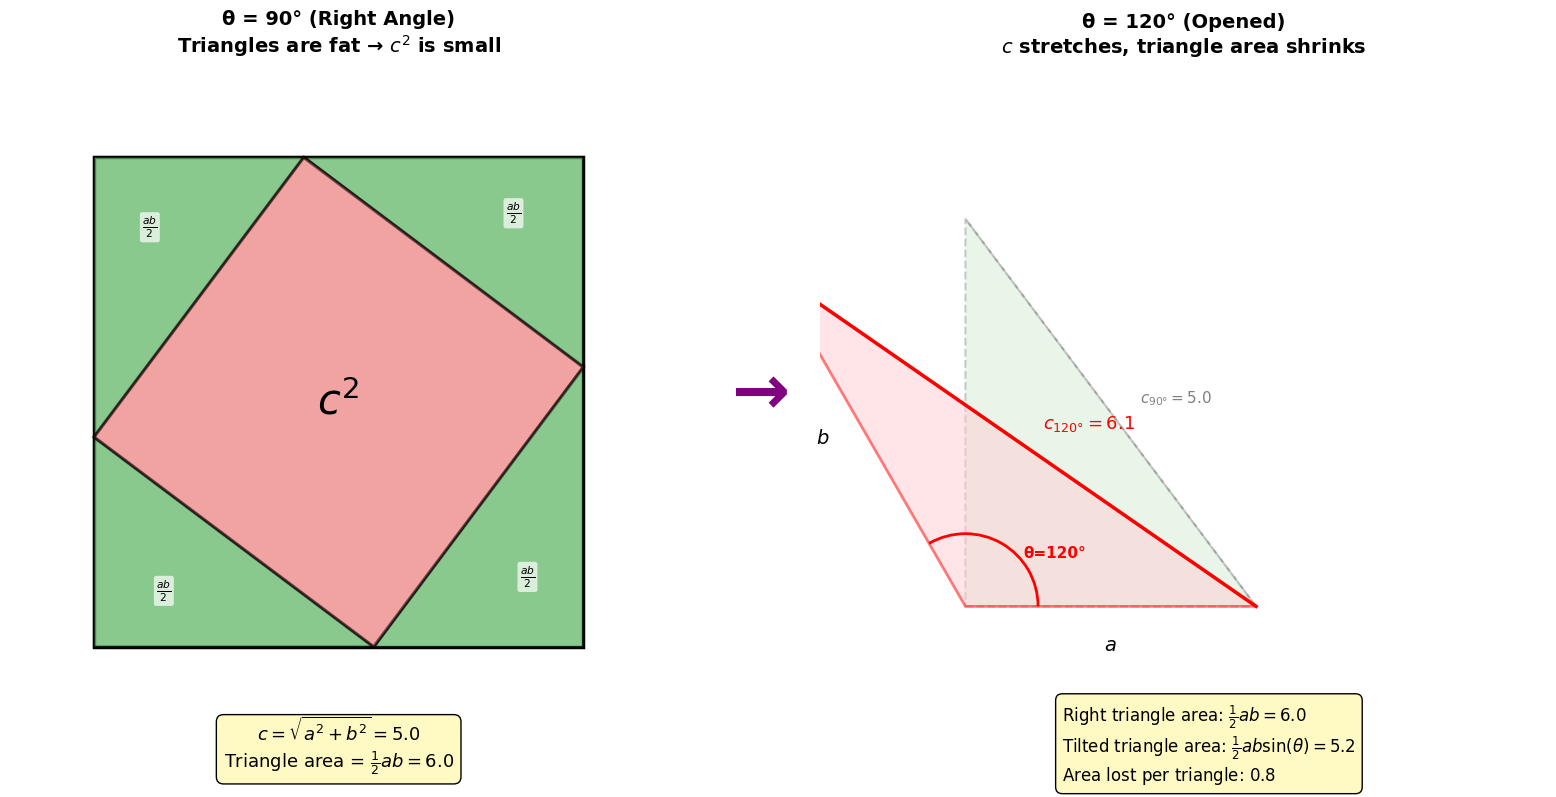

In [3]:
# === DIAGRAM 2: Side-by-side — 90° vs Tilted (θ > 90°) ===
# Shows how the inner "c² region" grows when you open the angle

a, b = 3, 4
s = a + b

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))

# ──────────── LEFT: θ = 90° (Pythagorean) ────────────
ax1.set_xlim(-1.2, s + 1.2)
ax1.set_ylim(-1.5, s + 1.2)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('θ = 90° (Right Angle)\nTriangles are fat → $c^2$ is small',
              fontsize=14, fontweight='bold', pad=15)

ax1.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))

tri_color_90 = '#66BB6A'
tris_90 = [
    [(0, 0), (b, 0), (0, a)],
    [(b, 0), (s, 0), (s, b)],
    [(s, b), (s, s), (a, s)],
    [(a, s), (0, s), (0, a)],
]
for t in tris_90:
    ax1.add_patch(plt.Polygon(t, fc=tri_color_90, ec='black', lw=1.5, alpha=0.75))

ax1.add_patch(plt.Polygon([(0, a), (b, 0), (s, b), (a, s)],
                           fc='#EF5350', ec='black', lw=2.5, alpha=0.5))
ax1.text(s/2, s/2, '$c^2$', fontsize=30, ha='center', va='center', fontweight='bold')

for (cx, cy) in [(1.0, 0.8), (s-0.8, 1.0), (s-1.0, s-0.8), (0.8, s-1.0)]:
    ax1.text(cx, cy, '$\\frac{ab}{2}$', fontsize=11, ha='center', va='center',
             bbox=dict(fc='white', ec='none', alpha=0.7, boxstyle='round,pad=0.15'))

c_90 = np.sqrt(a**2 + b**2)
ax1.text(s/2, -1.0, f'$c = \\sqrt{{a^2 + b^2}} = {c_90:.1f}$\nTriangle area = $\\frac{{1}}{{2}}ab = {0.5*a*b:.1f}$',
         fontsize=13, ha='center', va='top',
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# ──────────── RIGHT: θ = 120° (Opened) ────────────
theta_deg = 120
theta = np.radians(theta_deg)
# For the tilted version, b's effective projection changes
# The "effective b" along x-axis: b*cos(theta - 90°) = b*sin(theta_offset)
# When b tilts from 90° to theta, the right angle "opens"
# In the tilted arrangement, the inner quadrilateral vertices shift

# Compute c for this angle
c_tilt = np.sqrt(a**2 + b**2 - 2*a*b*np.cos(theta))

# We model the tilted configuration:
# b was vertical (perpendicular to a), now it tilts by delta = theta - 90°
delta = theta - np.pi/2  # extra tilt beyond 90°
b_x = b * np.sin(delta)  # horizontal component of tilt
b_y = b * np.cos(delta)  # vertical component (reduced from full b)

ax2.set_xlim(-1.2, s + 1.2)
ax2.set_ylim(-1.5, s + 1.2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f'θ = {theta_deg}° (Opened Past 90°)\nTriangles are thinner → $c^2$ grows!',
              fontsize=14, fontweight='bold', pad=15)

ax2.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))

# Tilted inner quadrilateral vertices
# Bottom-left triangle: legs are a (horizontal) and b_y (vertical), but b shifts right by b_x
p1 = (b_x, b_y)          # was (0, a) → now shifted
p2 = (b + b_x, 0 + 0)    # was (b, 0) → bottom stays anchored but shifts
# Recalculate for a symmetric arrangement inside the square
# Using the generalized construction:
# The four corner points of the inner quadrilateral in the (a+b) square
# when the triangle angle = theta
inner_pts = [
    (b_x, b_y),                    # bottom-left hyp corner
    (b + b_x, 0),                  # bottom-right hyp corner  — wrong, let me redo
]

# Better approach: directly show the triangle deformation
# Place four triangles in the corners, each with sides a, b and angle theta between them
# For a generalized (a+b) square with tilted triangles:
# Corner 1 (bottom-left): vertices at (0,0), along x by a, tilted b at angle theta from x
v1_bl = np.array([0, 0])
v2_bl = np.array([a, 0])
v3_bl = np.array([a - b*np.cos(theta), b*np.sin(theta)])

# But we need to fit 4 such triangles symmetrically in the square.
# Instead, let's show the deformation more directly with a single triangle comparison.

ax2.clear()
ax2.set_xlim(-1.2, s + 1.2)
ax2.set_ylim(-1.5, s + 1.2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f'θ = {theta_deg}° (Opened Past 90°)\nTriangles shrink → $c^2$ grows!',
              fontsize=14, fontweight='bold', pad=15)

ax2.add_patch(patches.Rectangle((0, 0), s, s, lw=2.5, ec='black', fc='#f5f5f5'))

# For the tilted case, the four triangles inside the (a+b) square are no longer right triangles.
# Their area is ½ a b sin(θ) each.
# Inner quadrilateral: still a quadrilateral with side c, but now c is larger.
# The inner vertices for a generalized tilt (rotating each triangle by the same delta):
# The construction works like the 90° case but with b_effective:
# project b onto the perpendicular direction: b_perp = b*cos(delta), b_parallel = b*sin(delta)
# where delta = theta - 90°

# Inner quad vertices (generalizing the Pythagorean construction):
# When theta=90°: (0,a),(b,0),(s,b),(a,s) — the classic
# When theta>90°: the inner quad "inflates"
# We parametrize: shift each inner vertex by b_x in the direction that opens the angle

ip1 = (0 + b_x, a - (b - b_y))  # bottom-left, was (0, a)
ip2 = (b + b_x, 0)               # bottom, was (b, 0)  
ip3 = (s - b_x, b + (b - b_y))   # top-right
ip4 = (a - b_x, s)               # top, was (a, s)

# Hmm, the exact construction is getting complicated. Let me use a cleaner parametrization.
# The key visual: show the actual triangle and how c changes.

# Actually, let me just show single triangles side by side instead of trying to fit into
# the (a+b) square, which gets geometrically complex for non-90° angles.

ax2.clear()

# --- SIMPLER AND CLEARER: show just the triangle at θ=120° overlaid on θ=90° ---
ax2.set_xlim(-1.5, 6)
ax2.set_ylim(-1.5, 5.5)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f'θ = {theta_deg}° (Opened)\n$c$ stretches, triangle area shrinks',
              fontsize=14, fontweight='bold', pad=15)

# 90° triangle (ghosted)
A_90 = np.array([0, 0])
B_90 = np.array([a, 0])
C_90 = np.array([0, b])  # b perpendicular to a
ax2.add_patch(plt.Polygon([A_90, B_90, C_90], fc='#C8E6C9', ec='gray', lw=1.5, alpha=0.4, ls='--'))
ax2.plot([B_90[0], C_90[0]], [B_90[1], C_90[1]], 'gray', lw=1.5, ls='--', alpha=0.5)
c_val_90 = np.linalg.norm(B_90 - C_90)
mid_90 = (B_90 + C_90) / 2
ax2.text(mid_90[0] + 0.3, mid_90[1] + 0.1, f'$c_{{90°}} = {c_val_90:.1f}$',
         fontsize=11, color='gray', ha='left')

# Tilted triangle (θ = 120°)
A_t = np.array([0, 0])
B_t = np.array([a, 0])
C_t = np.array([b * np.cos(theta), b * np.sin(theta)])  # b at angle theta from a
ax2.add_patch(plt.Polygon([A_t, B_t, C_t], fc='#FFCDD2', ec='red', lw=2, alpha=0.5))

# Side labels
ax2.text(a/2, -0.3, '$a$', fontsize=14, ha='center', va='top', fontweight='bold')
mid_b = (A_t + C_t) / 2
ax2.text(mid_b[0] - 0.4, mid_b[1], '$b$', fontsize=14, ha='right', va='center', fontweight='bold')
mid_c = (B_t + C_t) / 2
c_val_tilt = np.linalg.norm(B_t - C_t)
ax2.text(mid_c[0] + 0.3, mid_c[1] + 0.1, f'$c_{{120°}} = {c_val_tilt:.1f}$',
         fontsize=13, color='red', ha='left', fontweight='bold')

# The c side
ax2.plot([B_t[0], C_t[0]], [B_t[1], C_t[1]], 'r-', lw=2.5)

# Angle arc
angle_arc = patches.Arc((0, 0), 1.5, 1.5, angle=0, theta1=0, theta2=theta_deg,
                         lw=2, color='red')
ax2.add_patch(angle_arc)
ax2.text(0.6, 0.5, f'θ={theta_deg}°', fontsize=11, color='red', fontweight='bold')

# Area comparison
area_90 = 0.5 * a * b
area_tilt = 0.5 * a * b * np.sin(theta)
ax2.text(1.0, -1.0,
         f'Right triangle area: $\\frac{{1}}{{2}}ab = {area_90:.1f}$\n'
         f'Tilted triangle area: $\\frac{{1}}{{2}}ab\\sin(θ) = {area_tilt:.1f}$\n'
         f'Area lost per triangle: ${area_90 - area_tilt:.1f}$',
         fontsize=12, ha='left', va='top',
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

# Big equals sign between the two
fig.text(0.5, 0.5, '→', fontsize=50, ha='center', va='center', fontweight='bold', color='purple')

plt.tight_layout()
plt.show()

## Step 3 — Why $\cos(\theta)$? The "Rescaling" of $b$

When $b$ was perpendicular to $a$ (at 90°), the full length of $b$ contributed to the triangle's height.

When $b$ **tilts** by some angle $\theta$ from $a$:
- The "effective height" of the triangle becomes $b \sin(\theta)$ — the part of $b$ still perpendicular to $a$
- The "effective projection" onto $a$'s direction becomes $b \cos(\theta)$ — the part of $b$ that is now *aligned* with $a$

Think of $\cos(\theta)$ as a **rescaling factor**:

| $\theta$ | $\cos(\theta)$ | Meaning |
|:-:|:-:|:--|
| 0° | 1 | $b$ is perfectly aligned with $a$ (degenerate) |
| 60° | 0.5 | Half of $b$ aligns with $a$ |
| 90° | 0 | $b$ is perpendicular — **zero** alignment → Pythagorean! |
| 120° | −0.5 | $b$ works **against** $a$ — opens the triangle |
| 180° | −1 | $b$ is anti-aligned (degenerate) |

The term $2ab\cos(\theta)$ is the **total adjustment** to the four-triangle area when you tilt away from 90°.

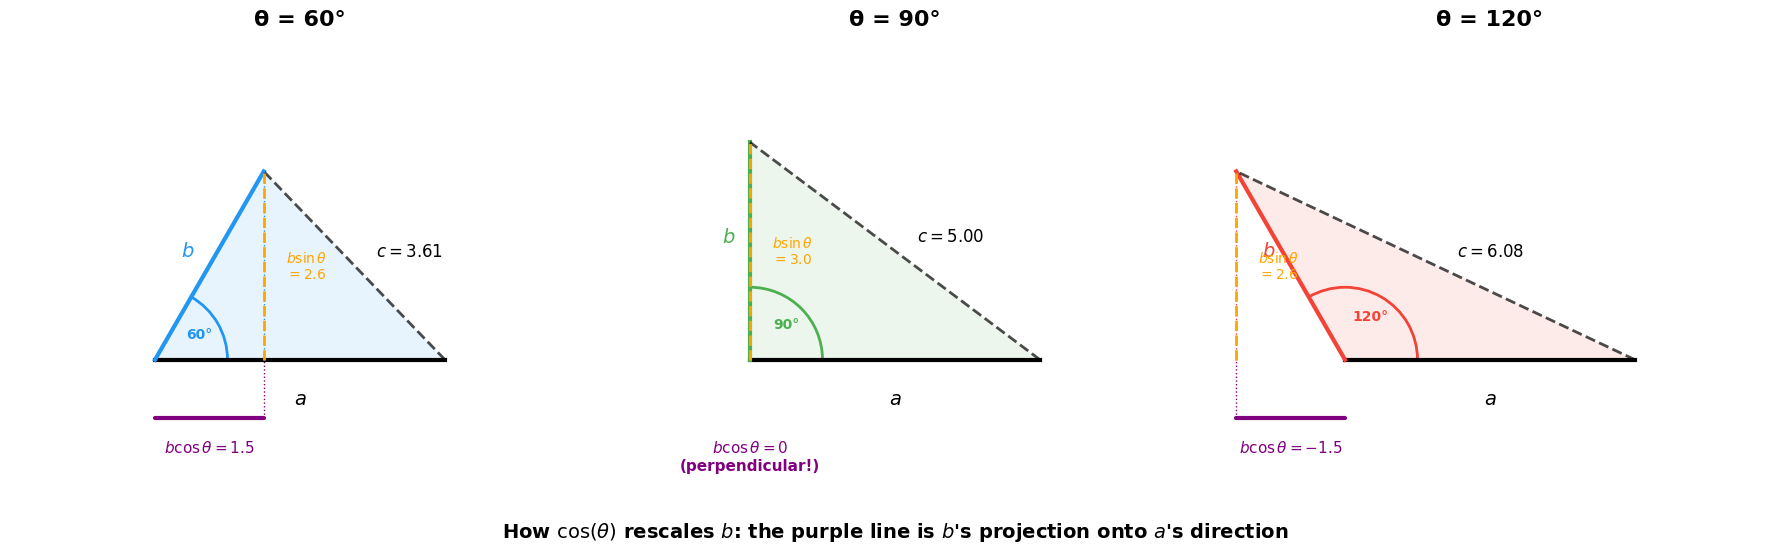

In [5]:
# === DIAGRAM 3: Visualising b's projection — why cos(θ) rescales b ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

a_len = 4
b_len = 3
angles_deg = [60, 90, 120]
colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, theta_deg, col in zip(axes, angles_deg, colors):
    theta = np.radians(theta_deg)
    
    ax.set_xlim(-2, 6)
    ax.set_ylim(-1.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'θ = {theta_deg}°', fontsize=16, fontweight='bold')
    
    # Side a along x-axis
    A = np.array([0, 0])
    B = np.array([a_len, 0])
    ax.plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=3)
    ax.text(a_len/2, -0.4, '$a$', fontsize=14, ha='center', va='top', fontweight='bold')
    
    # Side b at angle theta from a
    C = np.array([b_len * np.cos(theta), b_len * np.sin(theta)])
    ax.plot([A[0], C[0]], [A[1], C[1]], color=col, lw=3)
    mid_b = C / 2
    offset = np.array([-0.3, 0.2])
    ax.text(mid_b[0] + offset[0], mid_b[1] + offset[1], '$b$',
            fontsize=14, ha='center', va='center', fontweight='bold', color=col)
    
    # Side c (connecting B to C)
    ax.plot([B[0], C[0]], [B[1], C[1]], 'k--', lw=2, alpha=0.7)
    mid_c = (B + C) / 2
    c_val = np.linalg.norm(B - C)
    ax.text(mid_c[0] + 0.3, mid_c[1] + 0.2, f'$c = {c_val:.2f}$',
            fontsize=12, ha='left', va='center')
    
    # b·cos(θ) projection onto x-axis
    b_proj = b_len * np.cos(theta)
    if abs(b_proj) > 0.1:
        ax.plot([0, b_proj], [-0.8, -0.8], color='purple', lw=3, solid_capstyle='round')
        ax.plot([b_proj, b_proj], [-0.8, 0], 'purple', lw=1, ls=':')
        ax.plot([C[0], b_proj], [C[1], 0], color=col, lw=1, ls=':')
        ax.text(b_proj/2, -1.1, f'$b\\cos θ = {b_proj:.1f}$',
                fontsize=11, ha='center', va='top', color='purple', fontweight='bold')
    else:
        ax.text(0, -1.1, '$b\\cos θ = 0$\n(perpendicular!)',
                fontsize=11, ha='center', va='top', color='purple', fontweight='bold')
    
    # b·sin(θ) projection (height)
    b_height = b_len * np.sin(theta)
    ax.plot([b_proj, b_proj], [0, b_height], color='orange', lw=2, ls='--')
    ax.text(b_proj + 0.3, b_height/2, f'$b\\sin θ$\n$= {b_height:.1f}$',
            fontsize=10, ha='left', va='center', color='orange')
    
    # Angle arc
    arc_r = 1.0
    arc = patches.Arc((0, 0), arc_r*2, arc_r*2, angle=0, theta1=0, theta2=theta_deg,
                       lw=2, color=col)
    ax.add_patch(arc)
    ax.text(arc_r*0.7*np.cos(np.radians(theta_deg/2)),
            arc_r*0.7*np.sin(np.radians(theta_deg/2)),
            f'{theta_deg}°', fontsize=10, ha='center', va='center', color=col, fontweight='bold')
    
    # Triangle (filled lightly)
    ax.add_patch(plt.Polygon([A, B, C], fc=col, ec='none', alpha=0.1))

fig.suptitle('How $\\cos(\\theta)$ rescales $b$: the purple line is $b$\'s projection onto $a$\'s direction',
             fontsize=14, fontweight='bold', y=0.02)
plt.tight_layout()
plt.show()

## Step 4 — The Area Accounting: From Pythagorean to Law of Cosines

Here's the full story, connecting the Pythagorean proof to the Law of Cosines:

**At 90° (Pythagorean):**
$$(a+b)^2 = c^2 + 4 \cdot \frac{1}{2}ab = c^2 + 2ab$$
$$\Rightarrow c^2 = a^2 + b^2$$

**At any angle θ:**

The outer square is still $(a+b)^2 = a^2 + 2ab + b^2$. That hasn't changed.

But each triangle's area is now $\frac{1}{2}ab\sin(\theta)$ instead of $\frac{1}{2}ab$.

So the four triangles total $2ab\sin(\theta)$ instead of $2ab$.

The **difference** per triangle compared to the 90° case is:
$$\frac{1}{2}ab - \frac{1}{2}ab\sin(\theta) = \frac{1}{2}ab(1 - \sin(\theta))$$

But wait — let's think about this differently using **your** insight.

When $b$ tilts, the effective projection of $b$ onto $a$'s axis is $b\cos(\theta)$. The "lost" or "gained" rectangle has area $a \cdot b\cos(\theta)$, and there are **two** such interactions (from the four triangles working in pairs). This gives us:

$$c^2 = a^2 + b^2 - 2ab\cos(\theta)$$

Let's verify this works:
- At $\theta = 90°$: $\cos(90°) = 0$ → $c^2 = a^2 + b^2$ ✅
- At $\theta > 90°$: $\cos(\theta) < 0$ → $c^2 = a^2 + b^2 + (\text{positive})$ → $c$ gets bigger ✅
- At $\theta < 90°$: $\cos(\theta) > 0$ → $c^2 = a^2 + b^2 - (\text{positive})$ → $c$ gets smaller ✅

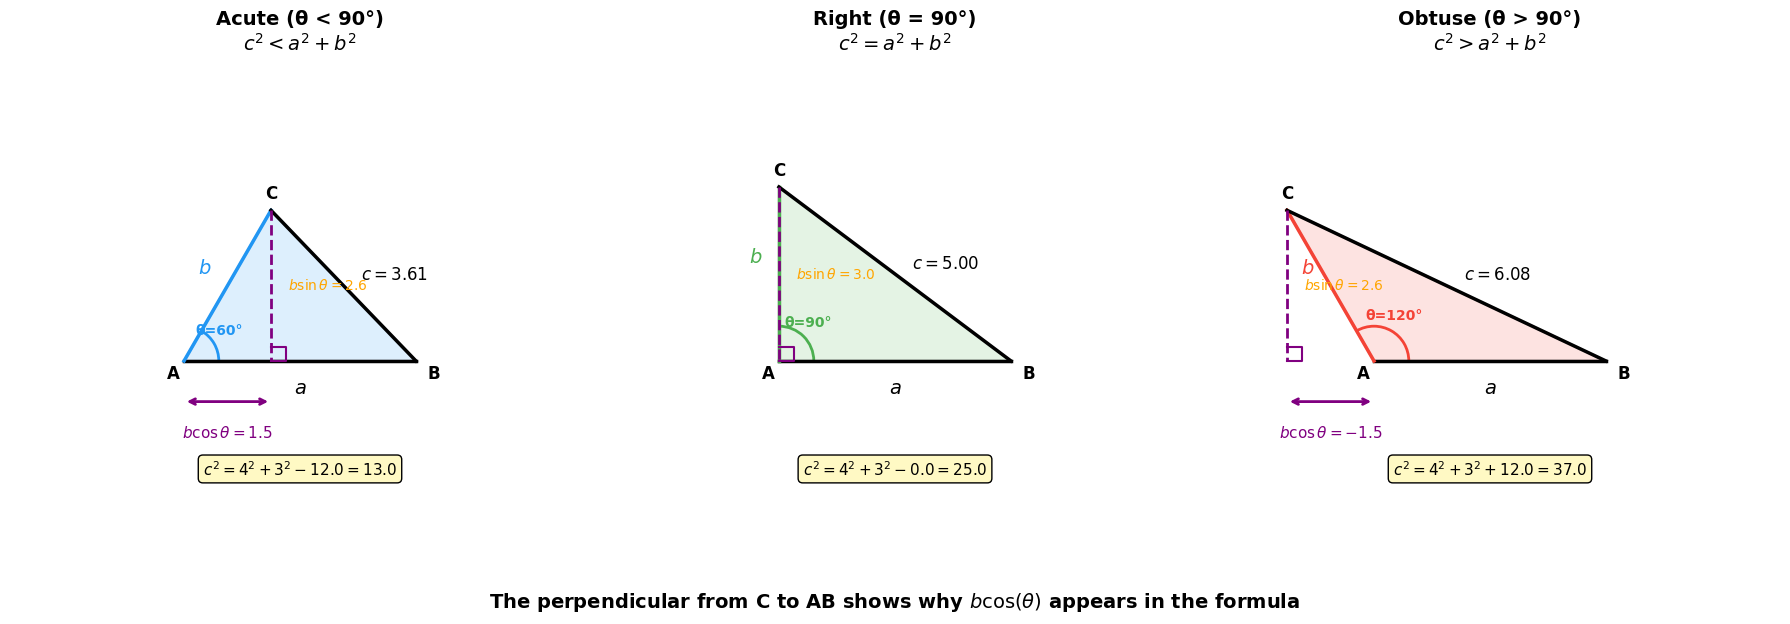

In [6]:
# === DIAGRAM 4: The Geometric Proof — Drop a perpendicular from C onto AB ===
# This shows where the 2ab·cos(θ) comes from geometrically

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

a_len, b_len = 4, 3
cases = [
    (60, 'Acute (θ < 90°)\n$c^2 < a^2 + b^2$', '#2196F3'),
    (90, 'Right (θ = 90°)\n$c^2 = a^2 + b^2$', '#4CAF50'),
    (120, 'Obtuse (θ > 90°)\n$c^2 > a^2 + b^2$', '#F44336'),
]

for ax, (theta_deg, title, col) in zip(axes, cases):
    theta = np.radians(theta_deg)
    
    ax.set_xlim(-3, 7)
    ax.set_ylim(-2, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Triangle vertices
    A = np.array([0, 0])
    B = np.array([a_len, 0])
    C = np.array([b_len * np.cos(theta), b_len * np.sin(theta)])
    c_val = np.linalg.norm(B - C)
    
    # Draw the triangle
    triangle = plt.Polygon([A, B, C], fc=col, ec='black', lw=2, alpha=0.15)
    ax.add_patch(triangle)
    ax.plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=2.5)
    ax.plot([A[0], C[0]], [A[1], C[1]], color=col, lw=2.5)
    ax.plot([B[0], C[0]], [B[1], C[1]], 'k-', lw=2.5)
    
    # Drop perpendicular from C to the x-axis (line AB extended)
    foot = np.array([C[0], 0])  # foot of perpendicular
    ax.plot([C[0], foot[0]], [C[1], foot[1]], 'purple', lw=2, ls='--')
    
    # Right angle marker at foot
    sq_size = 0.25
    ax.plot([foot[0], foot[0] + sq_size, foot[0] + sq_size, foot[0]],
            [sq_size, sq_size, 0, 0], 'purple', lw=1.5)
    
    # b·cos(θ) — the projection
    b_proj = b_len * np.cos(theta)
    if abs(b_proj) > 0.1:
        ax.annotate('', xy=(b_proj, -0.7), xytext=(0, -0.7),
                    arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
        ax.text(b_proj/2, -1.1, f'$b\\cos\\theta = {b_proj:.1f}$',
                fontsize=11, ha='center', va='top', color='purple', fontweight='bold')
    
    # Height label: b·sin(θ)
    b_height = b_len * np.sin(theta)
    ax.text(C[0] + 0.3, b_height/2, f'$b\\sin\\theta = {b_height:.1f}$',
            fontsize=10, ha='left', va='center', color='orange', fontweight='bold')
    
    # Label sides
    ax.text(a_len/2, -0.3, '$a$', fontsize=14, ha='center', va='top', fontweight='bold')
    mid_b = (A + C) / 2
    ax.text(mid_b[0] - 0.4, mid_b[1] + 0.2, '$b$', fontsize=14, ha='center', fontweight='bold', color=col)
    mid_c = (B + C) / 2
    ax.text(mid_c[0] + 0.3, mid_c[1] + 0.1, f'$c={c_val:.2f}$', fontsize=12, ha='left', fontweight='bold')
    
    # Vertex labels
    ax.text(A[0] - 0.3, A[1] - 0.3, 'A', fontsize=12, fontweight='bold')
    ax.text(B[0] + 0.2, B[1] - 0.3, 'B', fontsize=12, fontweight='bold')
    ax.text(C[0] - 0.1, C[1] + 0.2, 'C', fontsize=12, fontweight='bold')
    
    # Angle arc
    arc = patches.Arc(A, 1.2, 1.2, angle=0, theta1=0, theta2=theta_deg, lw=2, color=col)
    ax.add_patch(arc)
    ax.text(0.7*np.cos(np.radians(theta_deg/2)),
            0.7*np.sin(np.radians(theta_deg/2)) + 0.1,
            f'θ={theta_deg}°', fontsize=10, ha='center', color=col, fontweight='bold')
    
    # Show the formula result
    c2_formula = a_len**2 + b_len**2 - 2*a_len*b_len*np.cos(theta)
    correction = -2*a_len*b_len*np.cos(theta)
    sign = '+' if correction >= 0 else ''
    ax.text(2, -1.7,
            f'$c^2 = {a_len}^2 + {b_len}^2 {sign} {correction:.1f} = {c2_formula:.1f}$',
            fontsize=11, ha='center', va='top',
            bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))

plt.suptitle('The perpendicular from C to AB shows why $b\\cos(\\theta)$ appears in the formula',
             fontsize=14, fontweight='bold', y=0.02)
plt.tight_layout()
plt.show()

## Step 5 — The Interactive Tilt: Watch $c^2$ Grow and Shrink

This is the key visualisation. We sweep $\theta$ from 30° to 150° and watch:
1. **The triangle** — how the shape changes
2. **$c^2$ vs $a^2 + b^2$** — how the gap opens
3. **The $2ab\cos(\theta)$ correction** — the "area transfer" between the triangles and $c^2$

At $\theta = 90°$, the correction is zero and we get the Pythagorean theorem. As $\theta$ moves away from 90°, the correction term kicks in.

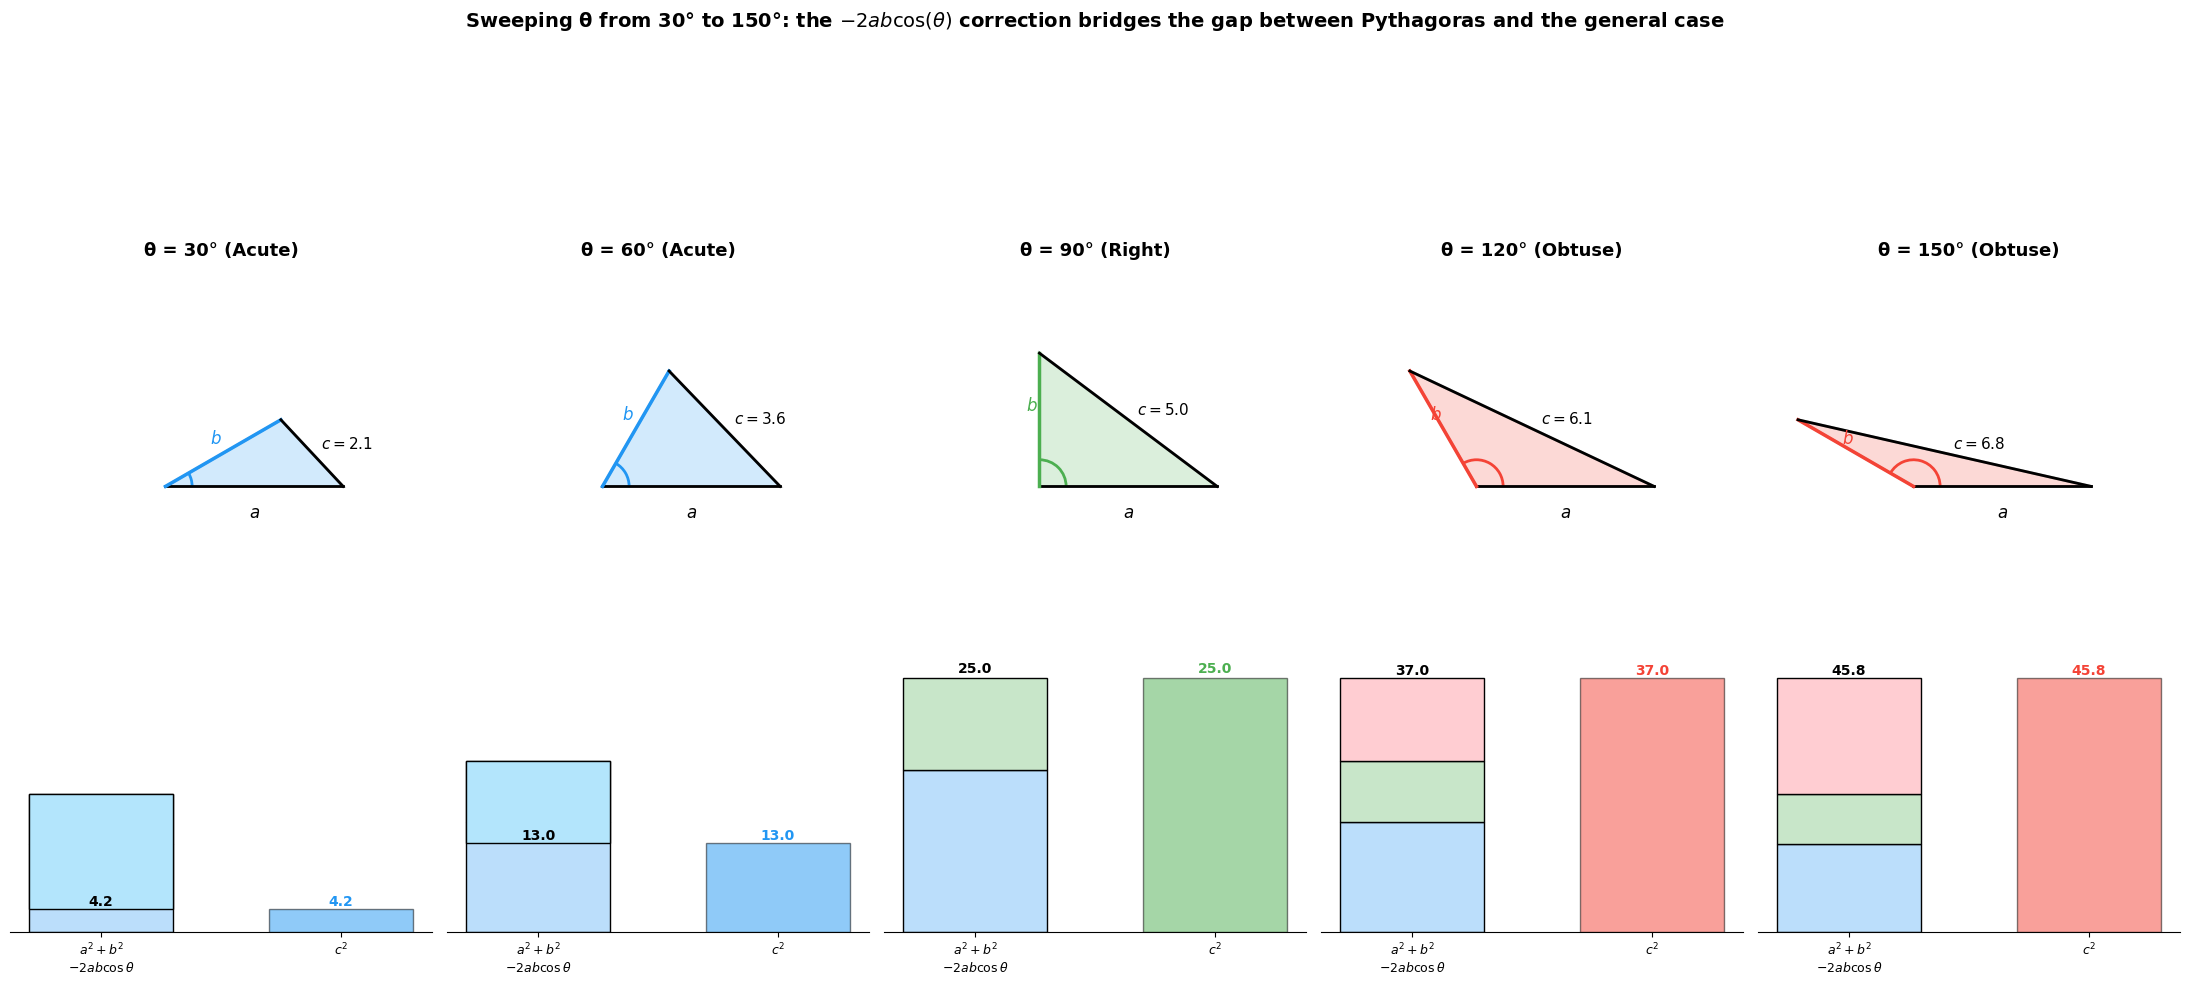

In [7]:
# === DIAGRAM 5: Multi-panel sweep — watch the tilt from 30° to 150° ===

a_len, b_len = 4, 3
angles = [30, 60, 90, 120, 150]

fig, axes = plt.subplots(2, 5, figsize=(22, 10),
                         gridspec_kw={'height_ratios': [3, 1.2]})

for i, theta_deg in enumerate(angles):
    theta = np.radians(theta_deg)
    ax_tri = axes[0, i]
    ax_bar = axes[1, i]
    
    # --- Triangle panel ---
    ax_tri.set_xlim(-3.5, 6)
    ax_tri.set_ylim(-1.5, 5)
    ax_tri.set_aspect('equal')
    ax_tri.axis('off')
    
    A = np.array([0, 0])
    B = np.array([a_len, 0])
    C = np.array([b_len * np.cos(theta), b_len * np.sin(theta)])
    c_val = np.linalg.norm(B - C)
    
    # Color based on whether obtuse or acute
    if theta_deg < 90:
        col = '#2196F3'
        label = 'Acute'
    elif theta_deg == 90:
        col = '#4CAF50'
        label = 'Right'
    else:
        col = '#F44336'
        label = 'Obtuse'
    
    ax_tri.set_title(f'θ = {theta_deg}° ({label})', fontsize=13, fontweight='bold')
    
    # Draw triangle
    ax_tri.add_patch(plt.Polygon([A, B, C], fc=col, ec='black', lw=2, alpha=0.2))
    ax_tri.plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=2)
    ax_tri.plot([A[0], C[0]], [A[1], C[1]], color=col, lw=2.5)
    ax_tri.plot([B[0], C[0]], [B[1], C[1]], 'k-', lw=2)
    
    # Angle arc
    arc = patches.Arc(A, 1.2, 1.2, angle=0, theta1=0, theta2=theta_deg, lw=2, color=col)
    ax_tri.add_patch(arc)
    
    # Labels
    ax_tri.text(a_len/2, -0.4, '$a$', fontsize=12, ha='center', va='top', fontweight='bold')
    mid_b = (A + C) / 2
    ax_tri.text(mid_b[0] - 0.3, mid_b[1] + 0.2, '$b$', fontsize=12, fontweight='bold', color=col)
    mid_c = (B + C) / 2
    ax_tri.text(mid_c[0] + 0.2, mid_c[1] + 0.1, f'$c={c_val:.1f}$', fontsize=11, ha='left')
    
    # --- Bar chart panel: area breakdown ---
    a2 = a_len**2
    b2 = b_len**2
    c2 = c_val**2
    correction = -2 * a_len * b_len * np.cos(theta)
    
    # Stacked bar: a² + b² and then the correction
    ax_bar.bar(0, a2, color='#BBDEFB', edgecolor='black', width=0.6, label='$a^2$')
    ax_bar.bar(0, b2, bottom=a2, color='#C8E6C9', edgecolor='black', width=0.6, label='$b^2$')
    if abs(correction) > 0.1:
        corr_col = '#FFCDD2' if correction > 0 else '#B3E5FC'
        ax_bar.bar(0, correction, bottom=a2+b2, color=corr_col, edgecolor='black',
                   width=0.6, label=f'$-2ab\\cos θ = {correction:+.1f}$')
    
    ax_bar.bar(1, c2, color=col, edgecolor='black', width=0.6, alpha=0.5, label=f'$c^2 = {c2:.1f}$')
    
    ax_bar.set_xticks([0, 1])
    ax_bar.set_xticklabels(['$a^2+b^2$\n$-2ab\\cos θ$', '$c^2$'], fontsize=9)
    ax_bar.set_ylim(0, max(a2 + b2 + abs(correction), c2) * 1.15)
    ax_bar.tick_params(left=False, labelleft=False)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['left'].set_visible(False)
    
    # Value labels on bars
    ax_bar.text(0, a2 + b2 + correction + 0.5, f'{a2 + b2 + correction:.1f}',
                ha='center', fontsize=10, fontweight='bold')
    ax_bar.text(1, c2 + 0.5, f'{c2:.1f}', ha='center', fontsize=10, fontweight='bold', color=col)

fig.suptitle('Sweeping θ from 30° to 150°: the $-2ab\\cos(\\theta)$ correction bridges '
             'the gap between Pythagoras and the general case',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — The Formal Proof (Using the Pythagorean Theorem!)

Now the algebraic proof, which follows directly from your intuition about dropping a perpendicular:

Given triangle with sides $a$, $b$, angle $\theta$ between them, and opposite side $c$.

**Drop a perpendicular** from vertex $C$ to side $a$ (extended if needed).

This creates two right triangles. The foot of the perpendicular splits the base into:
- $b\cos(\theta)$ — the projection of $b$ onto $a$'s direction
- $a - b\cos(\theta)$ — the remaining piece

The height is $h = b\sin(\theta)$.

Apply **Pythagorean theorem** to the right triangle containing side $c$:

$$c^2 = h^2 + (a - b\cos\theta)^2$$

$$= b^2\sin^2\theta + a^2 - 2ab\cos\theta + b^2\cos^2\theta$$

$$= b^2(\sin^2\theta + \cos^2\theta) + a^2 - 2ab\cos\theta$$

$$= b^2 + a^2 - 2ab\cos\theta$$

$$\boxed{c^2 = a^2 + b^2 - 2ab\cos\theta}$$

The $\sin^2\theta + \cos^2\theta = 1$ identity collapses the two projections of $b$ back into $b^2$. Beautiful. ✅

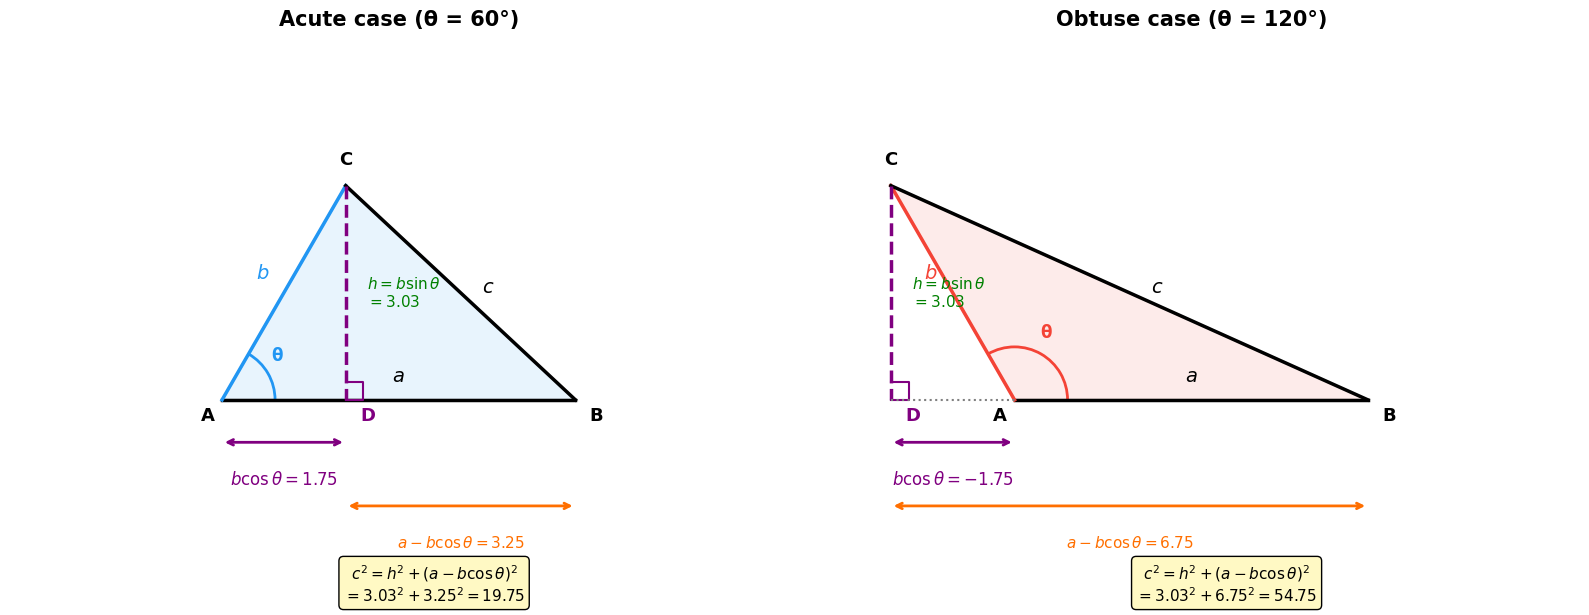

In [8]:
# === DIAGRAM 6: The formal proof visualised — the perpendicular drop ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

a_len, b_len = 5, 3.5

for ax, theta_deg, title in zip(axes, [60, 120],
                                 ['Acute case (θ = 60°)', 'Obtuse case (θ = 120°)']):
    theta = np.radians(theta_deg)
    
    ax.set_xlim(-3, 8)
    ax.set_ylim(-2.5, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    
    A = np.array([0, 0])
    B = np.array([a_len, 0])
    C = np.array([b_len * np.cos(theta), b_len * np.sin(theta)])
    foot = np.array([C[0], 0])
    
    c_val = np.linalg.norm(B - C)
    h = b_len * np.sin(theta)
    b_proj = b_len * np.cos(theta)
    
    # Fill the triangle
    col = '#2196F3' if theta_deg < 90 else '#F44336'
    ax.add_patch(plt.Polygon([A, B, C], fc=col, ec='black', lw=2, alpha=0.1))
    
    # Draw triangle sides
    ax.plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=2.5)
    ax.plot([A[0], C[0]], [A[1], C[1]], color=col, lw=2.5)
    ax.plot([B[0], C[0]], [B[1], C[1]], 'k-', lw=2.5)
    
    # Drop perpendicular
    ax.plot([C[0], foot[0]], [C[1], foot[1]], 'purple', lw=2.5, ls='--')
    
    # Right angle marker at foot
    sq = 0.25
    ax.plot([foot[0], foot[0] + sq, foot[0] + sq, foot[0]],
            [sq, sq, 0, 0], 'purple', lw=1.5)
    
    # Extend base if obtuse
    if b_proj < 0:
        ax.plot([b_proj, 0], [0, 0], 'gray', lw=1.5, ls=':')
    
    # Label the projection: b·cos(θ)
    ax.annotate('', xy=(b_proj, -0.6), xytext=(0, -0.6),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax.text(b_proj/2, -1.0, f'$b\\cos\\theta = {b_proj:.2f}$',
            fontsize=12, ha='center', va='top', color='purple', fontweight='bold')
    
    # Label the remaining piece: a - b·cos(θ)
    remaining = a_len - b_proj
    ax.annotate('', xy=(a_len, -1.5), xytext=(b_proj, -1.5),
                arrowprops=dict(arrowstyle='<->', color='#FF6F00', lw=2))
    ax.text((a_len + b_proj)/2, -1.9, f'$a - b\\cos\\theta = {remaining:.2f}$',
            fontsize=11, ha='center', va='top', color='#FF6F00', fontweight='bold')
    
    # Label height h = b·sin(θ)
    ax.text(C[0] + 0.3, h/2, f'$h = b\\sin\\theta$\n$= {h:.2f}$',
            fontsize=11, ha='left', va='center', color='green', fontweight='bold')
    
    # Label the sides
    ax.text(a_len/2, 0.2, '$a$', fontsize=14, ha='center', va='bottom', fontweight='bold')
    mid_b = (A + C) / 2
    ax.text(mid_b[0] - 0.4, mid_b[1] + 0.2, '$b$', fontsize=14, color=col, fontweight='bold')
    mid_c = (B + C) / 2
    ax.text(mid_c[0] + 0.3, mid_c[1], '$c$', fontsize=14, fontweight='bold')
    
    # Vertex labels
    ax.text(A[0] - 0.3, A[1] - 0.3, 'A', fontsize=13, fontweight='bold')
    ax.text(B[0] + 0.2, B[1] - 0.3, 'B', fontsize=13, fontweight='bold')
    ax.text(C[0] - 0.1, C[1] + 0.3, 'C', fontsize=13, fontweight='bold')
    ax.text(foot[0] + 0.2, foot[1] - 0.3, 'D', fontsize=13, fontweight='bold', color='purple')
    
    # Angle arc
    arc = patches.Arc(A, 1.5, 1.5, angle=0, theta1=0, theta2=theta_deg, lw=2, color=col)
    ax.add_patch(arc)
    ax.text(0.9*np.cos(np.radians(theta_deg/2)),
            0.9*np.sin(np.radians(theta_deg/2)) + 0.1,
            f'θ', fontsize=12, ha='center', color=col, fontweight='bold')
    
    # Show Pythagorean application
    ax.text(3, -2.3,
            f'$c^2 = h^2 + (a - b\\cos\\theta)^2$\n'
            f'$= {h:.2f}^2 + {remaining:.2f}^2 = {c_val**2:.2f}$',
            fontsize=11, ha='center', va='top',
            bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

## Step 7 — The Continuous Sweep: $c^2$ as a Function of $\theta$

Finally, let's plot $c^2$ as a smooth curve over all angles to see the full picture.

At $\theta = 90°$, we cross the Pythagorean line $a^2 + b^2$. The gap between the curve and that line is exactly $-2ab\cos(\theta)$.

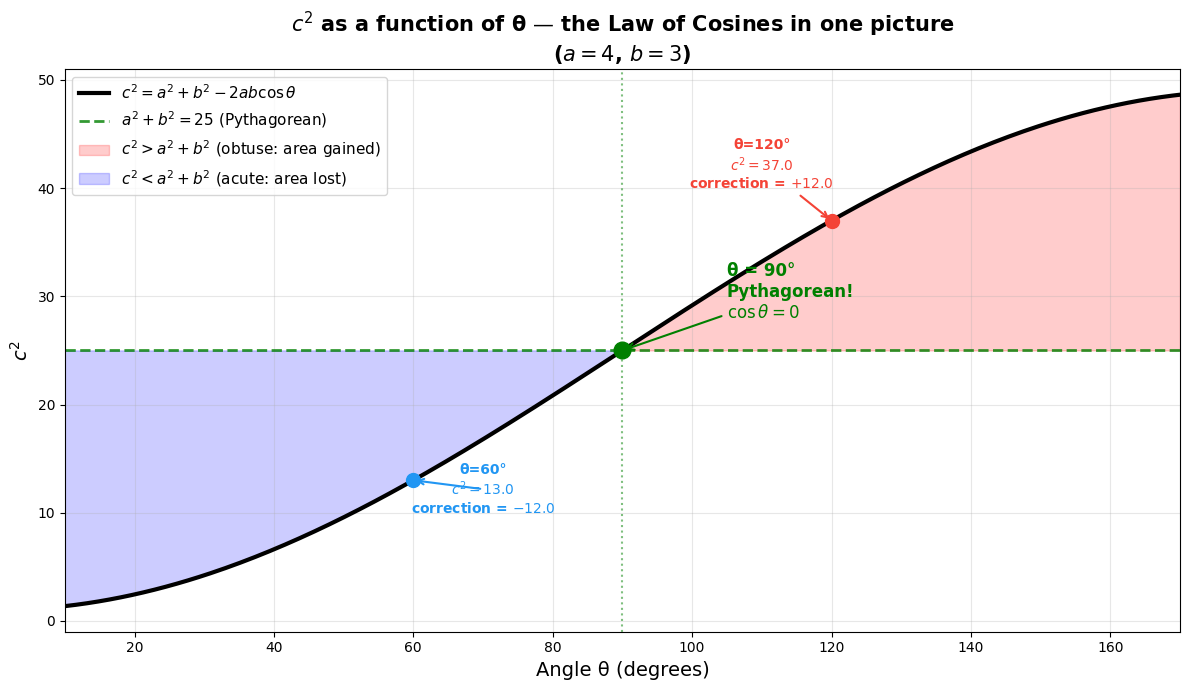

In [9]:
# === DIAGRAM 7: c² as a function of θ — the continuous sweep ===

a_len, b_len = 4, 3

thetas_deg = np.linspace(10, 170, 300)
thetas_rad = np.radians(thetas_deg)
c_squared = a_len**2 + b_len**2 - 2*a_len*b_len*np.cos(thetas_rad)
pyth_line = a_len**2 + b_len**2  # constant

fig, ax = plt.subplots(figsize=(12, 7))

# c² curve
ax.plot(thetas_deg, c_squared, 'k-', lw=3, label='$c^2 = a^2 + b^2 - 2ab\\cos\\theta$')

# Pythagorean line
ax.axhline(pyth_line, color='green', ls='--', lw=2, alpha=0.8,
           label=f'$a^2 + b^2 = {pyth_line}$ (Pythagorean)')

# Mark θ = 90°
ax.axvline(90, color='green', ls=':', lw=1.5, alpha=0.5)
ax.plot(90, pyth_line, 'go', ms=12, zorder=5)
ax.annotate('θ = 90°\nPythagorean!\n$\\cos θ = 0$', xy=(90, pyth_line),
            xytext=(105, pyth_line + 3),
            fontsize=12, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# Fill regions
ax.fill_between(thetas_deg, c_squared, pyth_line,
                where=c_squared > pyth_line,
                alpha=0.2, color='red', label='$c^2 > a^2+b^2$ (obtuse: area gained)')
ax.fill_between(thetas_deg, c_squared, pyth_line,
                where=c_squared < pyth_line,
                alpha=0.2, color='blue', label='$c^2 < a^2+b^2$ (acute: area lost)')

# Mark specific angles
for theta_mark, col, va_off in [(60, '#2196F3', -3), (120, '#F44336', 3)]:
    theta_r = np.radians(theta_mark)
    c2_val = a_len**2 + b_len**2 - 2*a_len*b_len*np.cos(theta_r)
    correction = -2*a_len*b_len*np.cos(theta_r)
    ax.plot(theta_mark, c2_val, 'o', color=col, ms=10, zorder=5)
    ax.annotate(f'θ={theta_mark}°\n$c^2 = {c2_val:.1f}$\ncorrection = ${correction:+.1f}$',
                xy=(theta_mark, c2_val),
                xytext=(theta_mark + (10 if theta_mark < 90 else -10), c2_val + va_off),
                fontsize=10, color=col, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))

ax.set_xlabel('Angle θ (degrees)', fontsize=14)
ax.set_ylabel('$c^2$', fontsize=14)
ax.set_title('$c^2$ as a function of θ — the Law of Cosines in one picture\n'
             f'($a = {a_len}$, $b = {b_len}$)',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(10, 170)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8 — Numerical Verification

Let's verify the formula with concrete numbers to make sure everything checks out.

In [10]:
# === Numerical verification ===

a, b = 4, 3

print("Law of Cosines: c² = a² + b² - 2ab·cos(θ)")
print(f"a = {a}, b = {b}")
print(f"a² + b² = {a**2 + b**2}")
print("=" * 55)
print(f"{'θ (deg)':>8} {'cos(θ)':>8} {'−2ab·cos(θ)':>12} {'c² (formula)':>13} {'c':>8}")
print("-" * 55)

for theta_deg in [30, 45, 60, 90, 120, 135, 150]:
    theta = np.radians(theta_deg)
    cos_val = np.cos(theta)
    correction = -2 * a * b * cos_val
    c_sq = a**2 + b**2 + correction
    c_val = np.sqrt(c_sq)
    print(f"{theta_deg:>8} {cos_val:>8.3f} {correction:>12.3f} {c_sq:>13.3f} {c_val:>8.3f}")

print("-" * 55)
print("\n✅ At θ = 90°, correction = 0 → Pythagorean theorem!")
print("✅ At θ > 90°, correction > 0 → c grows beyond √(a²+b²)")
print("✅ At θ < 90°, correction < 0 → c shrinks below √(a²+b²)")

Law of Cosines: c² = a² + b² - 2ab·cos(θ)
a = 4, b = 3
a² + b² = 25
 θ (deg)   cos(θ)  −2ab·cos(θ)  c² (formula)        c
-------------------------------------------------------
      30    0.866      -20.785         4.215    2.053
      45    0.707      -16.971         8.029    2.834
      60    0.500      -12.000        13.000    3.606
      90    0.000       -0.000        25.000    5.000
     120   -0.500       12.000        37.000    6.083
     135   -0.707       16.971        41.971    6.478
     150   -0.866       20.785        45.785    6.766
-------------------------------------------------------

✅ At θ = 90°, correction = 0 → Pythagorean theorem!
✅ At θ > 90°, correction > 0 → c grows beyond √(a²+b²)
✅ At θ < 90°, correction < 0 → c shrinks below √(a²+b²)


## Summary — Your "Aha!" in One Picture

The Law of Cosines is just the **Pythagorean theorem with an adjustment knob**:

$$c^2 = \underbrace{a^2 + b^2}_{\text{Pythagorean base}} - \underbrace{2ab\cos(\theta)}_{\text{tilt adjustment}}$$

Your intuition, step by step:
1. **Start** with the Pythagorean $(a+b)^2$ square containing 4 right triangles and the $c^2$ hole
2. **Tilt** side $b$ by changing the angle from 90° to $\theta$
3. The four triangles **shrink or grow** because $b$'s effective perpendicular height changes
4. $\cos(\theta)$ **rescales** $b$ — it tells you "how much of $b$ is aligned with $a$"
5. The area that the triangles lose gets **absorbed into $c^2$**, and vice versa
6. The total transfer is $2ab\cos(\theta)$ — two rectangle-pairs worth of rescaled overlap

When $\theta = 90°$, $\cos(\theta) = 0$, the knob is at zero, and you're back to Pythagoras. ✅